<a href="https://colab.research.google.com/github/raju-molla/Msc_Research/blob/unseen_attack/Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introduction

The increasing adoption of Internet of Things (IoT) devices and cloud-based network infrastructures has introduced significant security challenges. Intrusion Detection Systems (IDS) are essential for identifying malicious activities and protecting these environments. While traditional machine learning models such as Random Forest and XGBoost achieve high accuracy in detecting known attacks, they often struggle to identify unseen or zero-day threats.

To address this limitation, this notebook implements a **hybrid intrusion detection system** that combines supervised learning and deep learning-based anomaly detection. Specifically, the approach integrates **XGBoost** for detecting known attacks and an **LSTM Autoencoder** for identifying anomalous patterns in sequential network traffic. This hybrid design improves detection capability and provides a more realistic IDS suitable for modern IoT and cloud environments.

In addition, this work leverages a **cross-domain dataset** created by merging an IoT dataset and a benchmark network intrusion dataset. By aligning features and introducing a domain indicator, the model is trained on a more diverse and representative dataset.

The performance of the proposed system is evaluated using a comprehensive set of metrics, including classification performance (Accuracy, Precision, Recall, F1-score), ranking metrics (ROC-AUC, PR-AUC), error analysis (False Positive Rate and False Negative Rate), and computational efficiency (training and inference time).

---

## Notebook Objectives

The main objectives of this notebook are:

* To build a hybrid IDS combining **XGBoost and LSTM Autoencoder**
* To construct a **merged cross-domain dataset (IoT + network traffic)**
* To implement **sequence-based anomaly detection**
* To evaluate models using **advanced performance metrics**
* To compare baseline and hybrid models through **visualizations and analysis**



# 2. Import Libraries

This section imports all the required libraries for data processing, visualization, machine learning, and deep learning. It also ensures reproducibility by setting a fixed random seed.


In [1]:
# =========================
# 2. Import Libraries
# =========================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Utility
import time
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


# 3. Experiment Configuration

This section defines all key parameters used throughout the notebook, including dataset paths, model settings, and evaluation configurations. Centralizing these parameters ensures consistency and easy experimentation.


In [2]:
# =========================
# 3. Experiment Configuration
# =========================

# Random state
RANDOM_STATE = 42

# Data split
TEST_SIZE = 0.2
VAL_SIZE = 0.2

# LSTM sequence settings
SEQ_LEN = 10   # sequence length for LSTM

# Threshold selection method
THRESHOLD_METHOD = "percentile_99"  # options: mean_std, percentile_95, percentile_99

# Model parameters
XGB_PARAMS = {
    "n_estimators": 100,
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "eval_metric": "logloss"
}

RF_PARAMS = {
    "n_estimators": 100,
    "max_depth": None,
    "random_state": RANDOM_STATE
}

# Training parameters
EPOCHS = 20
BATCH_SIZE = 32

print("Configuration loaded successfully!")

Configuration loaded successfully!


# 4. Load Datasets

In this section, we load the datasets used to build the hybrid intrusion detection system.

Two types of datasets are used:

* **IoT Dataset (TON_IoT)**: Represents network traffic generated from IoT environments, including both normal and malicious activities.
* **Network Intrusion Dataset (CICIDS2017)**: A widely used benchmark dataset that includes realistic network traffic with multiple attack types such as DDoS, PortScan, Web Attacks, and Infiltration.

The CICIDS2017 dataset is composed of multiple files representing different days of network activity. In this study, multiple files are combined to ensure a comprehensive representation of both normal and attack traffic.

This combination enables the creation of a **cross-domain dataset**, which improves the realism and robustness of the intrusion detection system.

Basic inspection is performed to understand dataset structure, feature consistency, and class distribution before preprocessing.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =========================
# Load Datasets from Drive
# =========================

base_path = "/content/drive/MyDrive/CICIDS/"
# CICIDS files
cic_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

# Load and combine CICIDS
df_cic_list = []

for file in cic_files:
    path = base_path + file
    print(f"Loading {file}...")
    df_temp = pd.read_csv(path)
    df_cic_list.append(df_temp)

df_cic = pd.concat(df_cic_list, ignore_index=True)

print("\nCICIDS combined shape:", df_cic.shape)

Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Wednesday-workingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...

CICIDS combined shape: (2830743, 79)


In [5]:
# Load TON_IoT dataset
iot_path = '/content/drive/MyDrive/toniot/train_test_network.csv'

df_iot = pd.read_csv(iot_path)

print("IoT Dataset shape:", df_iot.shape)

IoT Dataset shape: (211043, 44)


In [6]:
# Preview
print("CICIDS Preview:")
display(df_cic.head())

print("\nIoT Preview:")
display(df_iot.head())

CICIDS Preview:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



IoT Preview:


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [7]:
print("CICIDS Columns:")
print(df_cic.columns)

print("\nIoT Columns:")
print(df_iot.columns)

CICIDS Columns:
Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Len

# 5. Exploratory Data Analysis

This section explores the structure and characteristics of both datasets before any preprocessing or transformation is applied.

The goal is to understand:

* data distribution
* feature types
* missing values
* class imbalance
* potential data quality issues

This analysis helps guide the preprocessing and feature selection steps in later sections.


#Missing Values

In [8]:
# Missing values
print("CICIDS Missing Values:")
print(df_cic.isnull().sum().sort_values(ascending=False).head(10))

print("\nIoT Missing Values:")
print(df_iot.isnull().sum().sort_values(ascending=False).head(10))

CICIDS Missing Values:
Flow Bytes/s                    1358
 Flow Duration                     0
 Destination Port                  0
 Total Backward Packets            0
Total Length of Fwd Packets        0
 Total Length of Bwd Packets       0
 Total Fwd Packets                 0
 Fwd Packet Length Max             0
 Fwd Packet Length Min             0
 Fwd Packet Length Std             0
dtype: int64

IoT Missing Values:
src_ip        0
src_port      0
dst_ip        0
dst_port      0
proto         0
service       0
duration      0
src_bytes     0
dst_bytes     0
conn_state    0
dtype: int64


#Duplicate check

In [9]:
print("CICIDS duplicates:", df_cic.duplicated().sum())
print("IoT duplicates:", df_iot.duplicated().sum())

CICIDS duplicates: 308381
IoT duplicates: 20569


#Basic Statistics

In [10]:
df_cic.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0


In [11]:
df_iot.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
src_port,211043.0,38646.519543,1.930727e+04,1.0,34608.0,44754.00000,51133.000000,6.552800e+04
dst_port,211043.0,3495.153770,1.019162e+04,0.0,65.0,80.00000,1253.000000,6.546700e+04
duration,211043.0,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,211043.0,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,211043.0,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09


In [12]:
df_cic.columns = df_cic.columns.str.strip()

#Feature Distribution Example

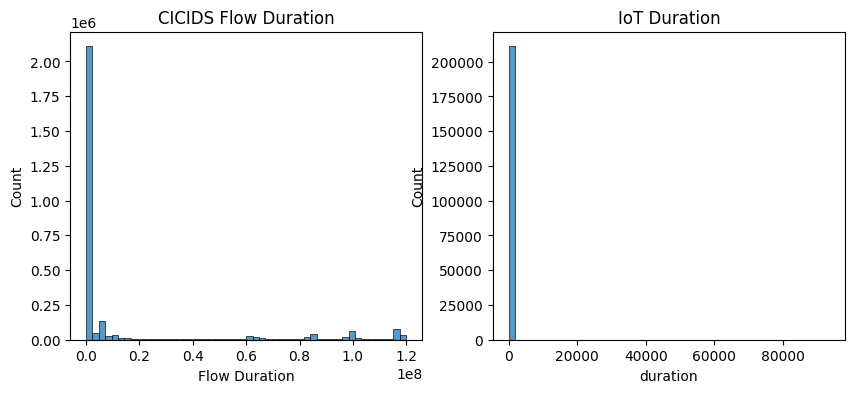

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_cic['Flow Duration'], bins=50)
plt.title("CICIDS Flow Duration")

plt.subplot(1,2,2)
sns.histplot(df_iot['duration'], bins=50)
plt.title("IoT Duration")

plt.show()

# 6. Feature Alignment

The IoT and CICIDS datasets contain heterogeneous features with different formats and semantics. To enable a unified learning framework, a common feature space is constructed by selecting semantically equivalent numerical features from both datasets.

Only core network traffic features are selected to ensure compatibility and avoid issues related to categorical variables and missing values.

The selected features include:

* Destination Port
* Flow Duration
* Forward Packet Count
* Backward Packet Count
* Forward Byte Count
* Backward Byte Count

These features are mapped into a unified representation across both datasets.

Additionally, a **domain indicator feature** is introduced:

* `0` for CICIDS (cloud/network traffic)
* `1` for IoT traffic

This allows the model to distinguish between different data sources and improves generalization.

This step is essential for enabling cross-domain learning in the proposed hybrid intrusion detection system.


#Clean Column Names

In [14]:
# Remove spaces from CICIDS column names
df_cic.columns = df_cic.columns.str.strip()

# Clean IoT columns too (good practice)
df_iot.columns = df_iot.columns.str.strip()

#Select and Rename CICIDS Features

In [15]:
# =========================
# CICIDS Feature Selection
# =========================

df_cic_selected = df_cic[[
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Label'
]].copy()

# Rename to unified names
df_cic_selected.columns = [
    'dst_port',
    'duration',
    'src_pkts',
    'dst_pkts',
    'src_bytes',
    'dst_bytes',
    'label'
]

print("CICIDS selected shape:", df_cic_selected.shape)

CICIDS selected shape: (2830743, 7)


#Select IoT Features

In [16]:
# =========================
# IoT Feature Selection
# =========================

df_iot_selected = df_iot[[
    'dst_port',
    'duration',
    'src_pkts',
    'dst_pkts',
    'src_bytes',
    'dst_bytes',
    'label'
]].copy()

print("IoT selected shape:", df_iot_selected.shape)

IoT selected shape: (211043, 7)


#Label Standardization

#CICIDS

In [17]:
df_cic_selected['label'] = df_cic_selected['label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

#IoT

In [18]:
print(df_iot['label'].unique())

[1 0]


In [19]:
df_iot_selected['label'] = df_iot_selected['label'].astype(int)

#Add Domain Feature

In [20]:
# 0 = CICIDS, 1 = IoT
df_cic_selected['domain'] = 0
df_iot_selected['domain'] = 1

#Merge Datasets

In [21]:
df_combined = pd.concat([df_cic_selected, df_iot_selected], ignore_index=True)

# Shuffle dataset
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined dataset shape:", df_combined.shape)

Combined dataset shape: (3041786, 8)


#Check

Index(['dst_port', 'duration', 'src_pkts', 'dst_pkts', 'src_bytes',
       'dst_bytes', 'label', 'domain'],
      dtype='object')


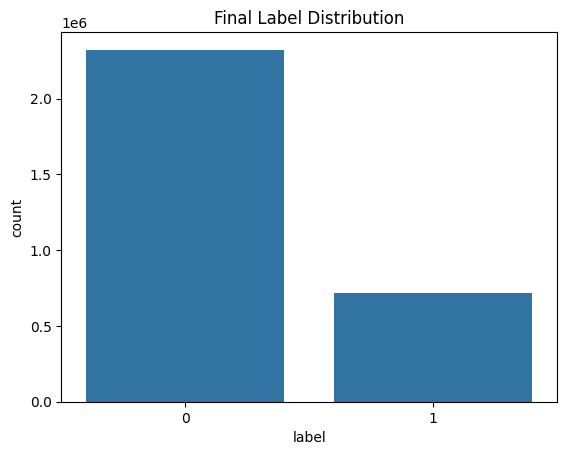

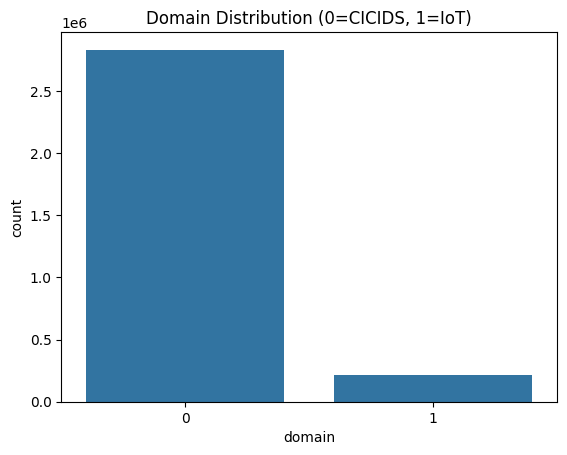

In [22]:
# Check columns
print(df_combined.columns)

# Label distribution
sns.countplot(x=df_combined['label'])
plt.title("Final Label Distribution")
plt.show()

# Domain distribution
sns.countplot(x=df_combined['domain'])
plt.title("Domain Distribution (0=CICIDS, 1=IoT)")
plt.show()

# 7. Data Cleaning and Preprocessing

This section prepares the dataset for model training by addressing data quality issues identified during exploratory analysis.

The following preprocessing steps are applied:

* Removal of duplicate records
* Handling of missing values
* Filtering of invalid values
* Transformation of skewed features
* Normalization of feature values

Log transformation is applied to reduce the effect of extreme outliers and skewed distributions, particularly in duration and byte-related features.

Finally, feature scaling is performed to ensure that all features contribute equally to the learning process, especially for deep learning models such as the LSTM Autoencoder.


#Remove Duplicates

In [23]:
# =========================
# Remove Duplicates
# =========================

print("Before removing duplicates:", df_combined.shape)

df_combined = df_combined.drop_duplicates()

print("After removing duplicates:", df_combined.shape)

Before removing duplicates: (3041786, 8)
After removing duplicates: (2338695, 8)


#Handle Missing Values

In [24]:
# =========================
# Handle Missing Values
# =========================

print("Missing values before:")
print(df_combined.isnull().sum())

# Fill missing values with 0 (safe for this dataset)
df_combined = df_combined.fillna(0)

print("Missing values after:")
print(df_combined.isnull().sum())

Missing values before:
dst_port     0
duration     0
src_pkts     0
dst_pkts     0
src_bytes    0
dst_bytes    0
label        0
domain       0
dtype: int64
Missing values after:
dst_port     0
duration     0
src_pkts     0
dst_pkts     0
src_bytes    0
dst_bytes    0
label        0
domain       0
dtype: int64


#Remove Invalid Values

In [25]:
# =========================
# Remove Invalid Values
# =========================

# Remove negative durations
df_combined = df_combined[df_combined['duration'] >= 0]

#Log Transformation

In [26]:
# =========================
# Log Transformation
# =========================

features_to_transform = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'src_pkts',
    'dst_pkts'
]

for col in features_to_transform:
    df_combined[col] = np.log1p(df_combined[col])

#Check

In [27]:
print(df_combined.head())
print(df_combined.describe())

   dst_port   duration  src_pkts  dst_pkts  src_bytes  dst_bytes  label  \
0        80  11.982341  1.609438  1.945910   7.722678   5.398163      0   
1     49666   3.583519  0.693147  1.386294   1.945910   2.944439      0   
2     56268   2.564949  0.693147  0.693147   1.945910   1.945910      0   
3        53  11.017218  0.693147  0.693147   4.077537   5.231109      0   
4       443  18.008933  3.332205  3.496508   6.906755   8.689464      0   

   domain  
0       0  
1       0  
2       0  
3       0  
4       0  
           dst_port      duration      src_pkts      dst_pkts     src_bytes  \
count  2.338647e+06  2.338647e+06  2.338647e+06  2.338647e+06  2.338647e+06   
mean   9.052665e+03  1.084065e+01  1.508764e+00  1.283534e+00  4.083208e+00   
std    1.928753e+04  5.559818e+00  8.532111e-01  9.459237e-01  2.379926e+00   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    5.300000e+01  5.442418e+00  6.931472e-01  6.931472e-01  2.564949e+00   
50%

In [28]:
print(df_combined['label'].value_counts())

label
0    1843938
1     494709
Name: count, dtype: int64


# 8. Train-Test Split

To evaluate the performance of the proposed intrusion detection system, the dataset is divided into training and testing subsets.

A stratified splitting strategy is used to preserve the distribution of normal and attack traffic in both sets. This ensures a fair and unbiased evaluation of model performance.

The test set remains completely unseen during training to simulate real-world deployment conditions and prevent data leakage.


In [29]:
# =========================
# Train-Test Split
# =========================

from sklearn.model_selection import train_test_split

# Features and target
X = df_combined.drop(columns=['label'])
y = df_combined['label']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1870917, 7)
Test shape: (467730, 7)


#Check Distribution

In [30]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
label
0    0.788464
1    0.211536
Name: proportion, dtype: float64

Test distribution:
label
0    0.788463
1    0.211537
Name: proportion, dtype: float64


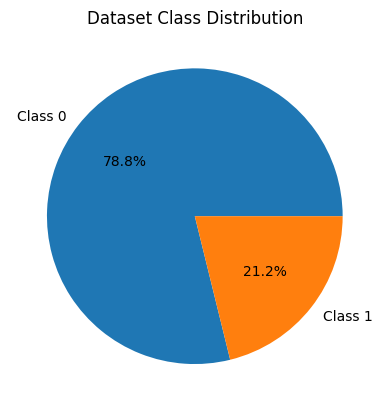

In [31]:
import matplotlib.pyplot as plt

labels = ['Class 0', 'Class 1']
train = [0.788464, 0.211536]

plt.figure()
plt.pie(train, labels=labels, autopct='%1.1f%%')
plt.title('Dataset Class Distribution')
plt.show()

#Section 9: Apply Scaling or normalization

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with clean aligned index
X_train = pd.DataFrame(X_train_scaled, columns=X.columns).reset_index(drop=True)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns).reset_index(drop=True)

# Reset target index too
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Scaling done correctly with aligned indices!")

Scaling done correctly with aligned indices!


In [33]:
print(X_train.describe())

           dst_port      duration      src_pkts      dst_pkts     src_bytes  \
count  1.870917e+06  1.870917e+06  1.870917e+06  1.870917e+06  1.870917e+06   
mean   1.380324e-01  5.828269e-01  1.226588e-01  1.020113e-01  1.937317e-01   
std    2.942191e-01  2.987731e-01  6.934084e-02  7.513898e-02  1.128909e-01   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    8.087282e-04  2.927881e-01  5.635209e-02  5.508055e-02  1.216699e-01   
50%    1.220722e-03  5.930129e-01  8.931596e-02  8.730061e-02  1.994521e-01   
75%    6.759747e-03  8.369643e-01  1.582003e-01  1.546307e-01  2.790790e-01   
max    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

          dst_bytes        domain  
count  1.870917e+06  1.870917e+06  
mean   2.267948e-01  4.364972e-02  
std    1.627597e-01  2.043146e-01  
min    0.000000e+00  0.000000e+00  
25%    9.289569e-02  0.000000e+00  
50%    2.437524e-01  0.000000e+00  
75%    3.779922e-01  0.000000e+00  


# 10. Random Forest Baseline

In this section, a Random Forest classifier is used as a baseline supervised learning model for intrusion detection.

Random Forest is an ensemble learning method that combines multiple decision trees to improve classification performance and reduce overfitting. It is widely used in intrusion detection research because of its robustness, interpretability, and strong performance on structured tabular data.

The model is trained on the prepared training set and evaluated on the unseen test set. In addition to class predictions, predicted probabilities are also generated for later use in ROC-AUC and PR-AUC analysis.

Training time and inference time are recorded to assess computational efficiency.


In [34]:
# =========================
# 10. Random Forest Baseline
# =========================

from sklearn.ensemble import RandomForestClassifier
import time

# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
start_time = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# Predict labels
start_time = time.time()
y_pred_rf = rf.predict(X_test)
rf_infer_time = time.time() - start_time

# Predict probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Print timing
print("Random Forest training completed.")
print(f"Training Time: {rf_train_time:.4f} seconds")
print(f"Inference Time: {rf_infer_time:.4f} seconds")

Random Forest training completed.
Training Time: 231.4435 seconds
Inference Time: 2.5818 seconds


#evaluation preview cell

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

cm_rf = confusion_matrix(y_test, y_pred_rf)

tn, fp, fn, tp = cm_rf.ravel()

print("RF Accuracy :", accuracy_score(y_test, y_pred_rf))
print("RF Precision:", precision_score(y_test, y_pred_rf))
print("RF Recall   :", recall_score(y_test, y_pred_rf))
print("RF F1-score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(cm_rf)

print("\nFPR:", fp / (fp + tn))
print("FNR:", fn / (fn + tp))

RF Accuracy : 0.9958287901139546
RF Precision: 0.9901852769045718
RF Recall   : 0.9900952072931617
RF F1-score : 0.9901402400505369

Confusion Matrix
[[367817    971]
 [   980  97962]]

FPR: 0.0026329490113561177
FNR: 0.009904792706838349


# 11. XGBoost Baseline

In this section, XGBoost is used as a second baseline supervised learning model for intrusion detection.

XGBoost is a gradient boosting algorithm designed for efficiency, scalability, and strong predictive performance. It is widely used in cybersecurity and intrusion detection tasks because it performs well on structured tabular datasets and can capture complex decision boundaries more effectively than many traditional classifiers.

The model is trained on the prepared training set and evaluated on the unseen test set. Both predicted class labels and predicted probabilities are generated for later use in advanced evaluation metrics such as ROC-AUC and PR-AUC.

Training time and inference time are also recorded to assess computational performance.


In [36]:
# =========================
# 11. XGBoost Baseline
# =========================

from xgboost import XGBClassifier
import time

# Initialize model
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train model
start_time = time.time()
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

# Predict labels
start_time = time.time()
y_pred_xgb = xgb.predict(X_test)
xgb_infer_time = time.time() - start_time

# Predict probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Print timing
print("XGBoost training completed.")
print(f"Training Time: {xgb_train_time:.4f} seconds")
print(f"Inference Time: {xgb_infer_time:.4f} seconds")

XGBoost training completed.
Training Time: 18.8250 seconds
Inference Time: 1.1079 seconds


#evaluation preview cell for XGB

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

tn, fp, fn, tp = cm_xgb.ravel()

print("XGB Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("XGB Precision:", precision_score(y_test, y_pred_xgb))
print("XGB Recall   :", recall_score(y_test, y_pred_xgb))
print("XGB F1-score :", f1_score(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(cm_xgb)

print("\nFPR:", fp / (fp + tn))
print("FNR:", fn / (fn + tp))

XGB Accuracy : 0.9959976909755628
XGB Precision: 0.9939044246346725
XGB Recall   : 0.9871338764124437
XGB F1-score : 0.9905075807514832

Confusion Matrix
[[368189    599]
 [  1273  97669]]

FPR: 0.0016242394004143301
FNR: 0.012866123587556346


# 12. Normal Traffic Extraction

In this section, only normal traffic samples are extracted from the training set for anomaly detection modeling.

The LSTM Autoencoder is trained exclusively on normal traffic so that it can learn the underlying patterns of benign behavior. During testing, samples that deviate significantly from this learned normal pattern can be identified as anomalous or malicious.

This approach is commonly used in anomaly-based intrusion detection, where the reconstruction error of the autoencoder is used to distinguish normal traffic from potential attacks.


In [38]:
# =========================
# 12. Normal Traffic Extraction
# =========================

# Extract only normal samples from training data
X_train_normal = X_train[y_train == 0].copy()

# Keep full test set for later anomaly evaluation
X_test_full = X_test.copy()
y_test_full = y_test.copy()

print("Normal training samples shape:", X_train_normal.shape)
print("Full test samples shape:", X_test_full.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nNormal-only training label count:")
print((y_train == 0).sum())

Normal training samples shape: (1475150, 7)
Full test samples shape: (467730, 7)

Training label distribution:
label
0    1475150
1     395767
Name: count, dtype: int64

Normal-only training label count:
1475150


# 13. Sequence Construction

In this section, the tabular traffic data is transformed into sequential windows for use in the LSTM Autoencoder.

Because LSTM models are designed to learn temporal dependencies, individual records are grouped into fixed-length sequences. The autoencoder is trained on sequences of normal traffic only, while testing is performed on sequences derived from the full test set.

For the test set, a sequence is labeled as anomalous if at least one record within the sequence corresponds to an attack. This allows the anomaly detector to identify suspicious temporal patterns rather than only isolated samples.


In [39]:
# =========================
# 13. Sequence Construction
# =========================

import numpy as np

SEQ_LEN = 10

def create_sequences(X, y=None, seq_len=10):
    X_values = X.values if hasattr(X, "values") else X

    X_seq = []
    y_seq = []

    for i in range(len(X_values) - seq_len + 1):
        X_seq.append(X_values[i:i+seq_len])

        if y is not None:
            window_labels = y.iloc[i:i+seq_len] if hasattr(y, "iloc") else y[i:i+seq_len]
            y_seq.append(1 if np.any(window_labels == 1) else 0)

    X_seq = np.array(X_seq)

    if y is not None:
        return X_seq, np.array(y_seq)
    return X_seq

#Create training sequences from normal traffic only

In [40]:
X_train_normal_seq = create_sequences(X_train_normal, seq_len=SEQ_LEN)

print("Normal training sequence shape:", X_train_normal_seq.shape)

Normal training sequence shape: (1475141, 10, 7)


#Create test sequences from full test set

In [41]:
X_test_seq, y_test_seq = create_sequences(X_test_full, y_test_full, seq_len=SEQ_LEN)

print("Test sequence shape:", X_test_seq.shape)
print("Test sequence labels shape:", y_test_seq.shape)

Test sequence shape: (467721, 10, 7)
Test sequence labels shape: (467721,)


#Check sequence label distribution

In [42]:
print("Test sequence label distribution:")
print(pd.Series(y_test_seq).value_counts())

Test sequence label distribution:
1    424427
0     43294
Name: count, dtype: int64


# 14. LSTM Autoencoder Model

In this section, an LSTM Autoencoder is constructed for anomaly-based intrusion detection.

The model is trained exclusively on sequences of normal traffic so that it can learn the temporal structure of benign behavior. During testing, sequences with high reconstruction error are considered anomalous and may correspond to malicious activity.

The encoder compresses each input sequence into a lower-dimensional representation, while the decoder attempts to reconstruct the original sequence. Reconstruction error is later used as the anomaly score.


In [43]:
# =========================
# 14. LSTM Autoencoder Model
# =========================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

n_features = X_train_normal_seq.shape[2]

inputs = Input(shape=(SEQ_LEN, n_features))

# Encoder
encoded = LSTM(64, activation='tanh', return_sequences=True)(inputs)
encoded = LSTM(32, activation='tanh', return_sequences=False)(encoded)

# Decoder
decoded = RepeatVector(SEQ_LEN)(encoded)
decoded = LSTM(32, activation='tanh', return_sequences=True)(decoded)
decoded = LSTM(64, activation='tanh', return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(n_features))(decoded)

# Model
lstm_autoencoder = Model(inputs, outputs)
lstm_autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

lstm_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 7)          │           455 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,455 (251.78 KB)

 Trainable params: 64,455 (251.78 KB)

 Non-trainable params: 0 (0.00 B)

#training section

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

history = lstm_autoencoder.fit(
    X_train_normal_seq,
    X_train_normal_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

lstm_train_time = time.time() - start_time

print("LSTM Autoencoder training time:", lstm_train_time)

Epoch 1/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 233s 11ms/step - loss: 0.0068 - val_loss: 0.0017
Epoch 2/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 269s 11ms/step - loss: 9.9380e-04 - val_loss: 6.4901e-04
Epoch 3/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 227s 11ms/step - loss: 5.2377e-04 - val_loss: 4.8128e-04
Epoch 4/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 226s 11ms/step - loss: 4.1287e-04 - val_loss: 4.1077e-04
Epoch 5/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 226s 11ms/step - loss: 3.5894e-04 - val_loss: 3.4419e-04
Epoch 6/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 225s 11ms/step - loss: 3.2311e-04 - val_loss: 3.2136e-04
Epoch 7/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 261s 11ms/step - loss: 2.8800e-04 - val_loss: 2.7568e-04
Epoch 8/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 225s 11ms/step - loss: 2.6704e-04 - val_loss: 2.6221e-04
Epoch 9/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 226s 11ms/step - loss: 2.5346e-04 - val_loss: 2.4199e-04
Epoch 10/10
20745/20745 ━━━━━━━━━━━━━━━━━━━━ 233s 11ms/step - loss: 2.2858e-04 - val_loss: 2.2174e-

#Example for long data

In [45]:
# sample_size = 200000
# idx = np.random.choice(len(X_train_normal_seq), sample_size, replace=False)
# X_train_normal_seq_sample = X_train_normal_seq[idx]

In [46]:
# history = lstm_autoencoder.fit(
#     X_train_normal_seq_sample,
#     X_train_normal_seq_sample,
#     epochs=10,
#     batch_size=64,
#     validation_split=0.1,
#     callbacks=[early_stop],
#     shuffle=True,
#     verbose=1
# )

# 15. Reconstruction Error and Threshold Selection

In this section, the trained LSTM Autoencoder is used to reconstruct input sequences. The reconstruction error is then calculated for each sequence.

Because the model is trained only on normal traffic, normal sequences are expected to produce low reconstruction error, while anomalous or malicious sequences are expected to produce higher error.

A threshold is defined to separate normal and anomalous sequences. Sequences with reconstruction error above the threshold are classified as anomalies.


In [47]:
# =========================
# 15. Reconstruction Error and Threshold Selection
# =========================

# Reconstruct test sequences
X_test_recon = lstm_autoencoder.predict(X_test_seq, batch_size=256)

# Compute reconstruction error per sequence
reconstruction_error = np.mean(np.square(X_test_seq - X_test_recon), axis=(1, 2))

print("Reconstruction error shape:", reconstruction_error.shape)
print("First 10 reconstruction errors:", reconstruction_error[:10])

1828/1828 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
Reconstruction error shape: (467721,)
First 10 reconstruction errors: [0.0004278  0.00043334 0.00037327 0.00032677 0.00032939 0.00028881
 0.00021528 0.00022457 0.00015809 0.00013011]


#Threshold selection

First use percentile-based threshold:

In [48]:
threshold = np.percentile(reconstruction_error, 95)
print("Threshold:", threshold)

Threshold: 0.0013465783268732552


#Predict anomalies

In [49]:
y_pred_ae = (reconstruction_error > threshold).astype(int)

print("Predicted anomaly distribution:")
print(pd.Series(y_pred_ae).value_counts())

Predicted anomaly distribution:
0    444335
1     23386
Name: count, dtype: int64


#Quick evaluation

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("LSTM Autoencoder Performance:")
print("Accuracy :", accuracy_score(y_test_seq, y_pred_ae))
print("Precision:", precision_score(y_test_seq, y_pred_ae))
print("Recall   :", recall_score(y_test_seq, y_pred_ae))
print("F1-score :", f1_score(y_test_seq, y_pred_ae))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_seq, y_pred_ae))

LSTM Autoencoder Performance:
Accuracy : 0.14211891277064745
Precision: 0.9955528948943813
Recall   : 0.054855134098443316
F1-score : 0.10398090274288598

Confusion Matrix:
[[ 43190    104]
 [401145  23282]]


#Plot reconstruction error distribution

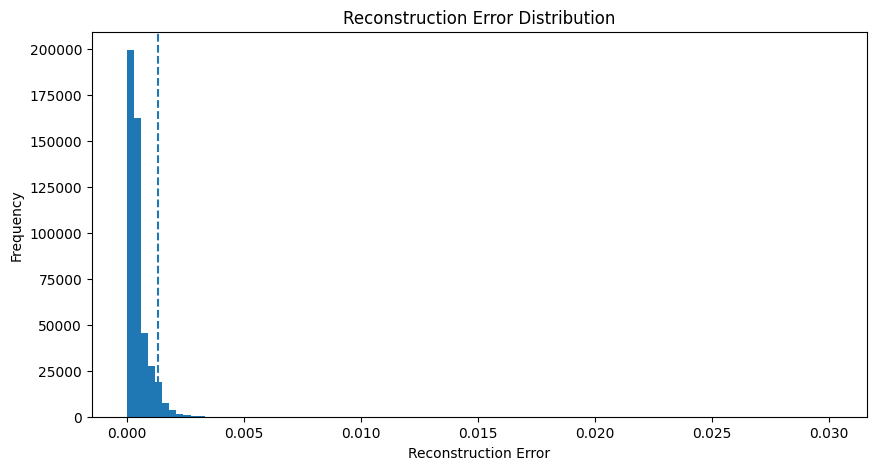

In [51]:
plt.figure(figsize=(10,5))
plt.hist(reconstruction_error, bins=100)
plt.axvline(threshold, linestyle='--')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

#different Threshold

In [52]:
# =========================
# Threshold Tuning
# =========================

thresholds = [
    np.percentile(reconstruction_error, 95),
    np.percentile(reconstruction_error, 90),
    np.percentile(reconstruction_error, 85),
    np.percentile(reconstruction_error, 80),
    reconstruction_error.mean() + 2 * reconstruction_error.std(),
    reconstruction_error.mean() + 1.5 * reconstruction_error.std()
]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for th in thresholds:
    y_pred_temp = (reconstruction_error > th).astype(int)

    acc = accuracy_score(y_test_seq, y_pred_temp)
    prec = precision_score(y_test_seq, y_pred_temp)
    rec = recall_score(y_test_seq, y_pred_temp)
    f1 = f1_score(y_test_seq, y_pred_temp)

    results.append([th, acc, prec, rec, f1])

# Show results
import pandas as pd

df_results = pd.DataFrame(results, columns=[
    "Threshold", "Accuracy", "Precision", "Recall", "F1-score"
])

print(df_results)

   Threshold  Accuracy  Precision    Recall  F1-score
0   0.001347  0.142119   0.995553  0.054855  0.103981
1   0.001080  0.191294   0.993650  0.109501  0.197263
2   0.000834  0.239788   0.990749  0.163771  0.281080
3   0.000681  0.288467   0.989759  0.218144  0.357495
4   0.001450  0.129682   0.995830  0.041077  0.078899
5   0.001213  0.165011   0.994859  0.080252  0.148523


#LSTM Prediction
- Reconstruction korbo
- Error calculate korbo
- hreshold use kore anomaly detect korbo

In [53]:
# =========================
# LSTM Prediction (Reconstruction)
# =========================

X_test_recon = lstm_autoencoder.predict(X_test_seq, batch_size=256)

print("Reconstructed shape:", X_test_recon.shape)

1828/1828 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Reconstructed shape: (467721, 10, 7)


In [54]:
# =========================
# Compute Reconstruction Error
# =========================

reconstruction_error = np.mean(
    np.square(X_test_seq - X_test_recon),
    axis=(1, 2)
)

print("Error shape:", reconstruction_error.shape)
print("First 10 errors:", reconstruction_error[:10])

Error shape: (467721,)
First 10 errors: [0.0004278  0.00043334 0.00037327 0.00032677 0.00032939 0.00028881
 0.00021528 0.00022457 0.00015809 0.00013011]


In [55]:
best_threshold = 0.001014

In [56]:
# =========================
# LSTM Prediction (Final)
# =========================

y_pred_ae = (reconstruction_error > best_threshold).astype(int)

print("Predicted labels:")
print(pd.Series(y_pred_ae).value_counts())

Predicted labels:
0    414935
1     52786
Name: count, dtype: int64


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

cm_ae = confusion_matrix(y_test_seq, y_pred_ae)

tn, fp, fn, tp = cm_ae.ravel()

print("AE Accuracy :", accuracy_score(y_test_seq, y_pred_ae))
print("AE Precision:", precision_score(y_test_seq, y_pred_ae))
print("AE Recall   :", recall_score(y_test_seq, y_pred_ae))
print("AE F1-score :", f1_score(y_test_seq, y_pred_ae))

print("\nConfusion Matrix")
print(cm_ae)

print("\nFPR:", fp / (fp + tn))
print("FNR:", fn / (fn + tp))

AE Accuracy : 0.2038522965614116
AE Precision: 0.9930473989315349
AE Recall   : 0.12350533778482518
AE F1-score : 0.2196880638205581

Confusion Matrix
[[ 42927    367]
 [372008  52419]]

FPR: 0.008476925209035894
FNR: 0.8764946622151748


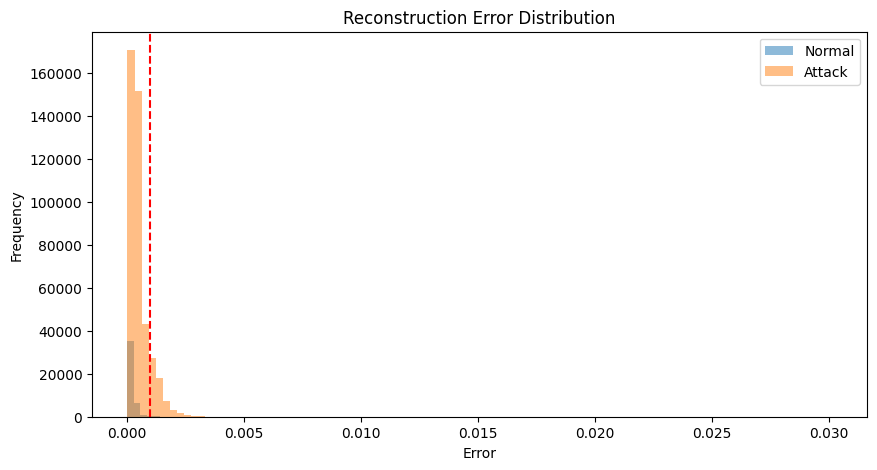

In [58]:
plt.figure(figsize=(10,5))

plt.hist(reconstruction_error[y_test_seq == 0], bins=100, alpha=0.5, label="Normal")
plt.hist(reconstruction_error[y_test_seq == 1], bins=100, alpha=0.5, label="Attack")

plt.axvline(best_threshold, linestyle='--', color='red')
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

# 16. Hybrid Fusion

In this section, the predictions from XGBoost and the LSTM Autoencoder are combined to form a hybrid intrusion detection model.

XGBoost is responsible for supervised detection of known attack patterns, while the LSTM Autoencoder provides anomaly-based detection by identifying sequences with high reconstruction error.

Because the LSTM Autoencoder operates on sequence-level inputs, XGBoost predictions are also converted to sequence-level form. A sequence is labeled as malicious if at least one record within the sequence is predicted as an attack by XGBoost.

The final hybrid prediction is obtained using a logical OR operation:

* if either XGBoost or the LSTM Autoencoder predicts an attack, the final output is attack
* otherwise, the sequence is considered normal

This fusion strategy improves robustness by combining the strengths of supervised classification and anomaly detection.


#Convert XGBoost predictions to sequence-level

In [59]:
# =========================
# 16. Hybrid Fusion
# =========================

def create_sequence_labels_from_row_predictions(row_preds, seq_len=10):
    seq_preds = []
    for i in range(len(row_preds) - seq_len + 1):
        window = row_preds[i:i+seq_len]
        seq_preds.append(1 if np.any(window == 1) else 0)
    return np.array(seq_preds)

# Convert XGBoost row-level predictions to sequence-level
y_pred_xgb_seq = create_sequence_labels_from_row_predictions(y_pred_xgb, seq_len=SEQ_LEN)

print("XGB sequence prediction shape:", y_pred_xgb_seq.shape)
print("AE prediction shape:", y_pred_ae.shape)
print("True sequence label shape:", y_test_seq.shape)

XGB sequence prediction shape: (467721,)
AE prediction shape: (467721,)
True sequence label shape: (467721,)


#Hybrid OR fusion

In [60]:
# Hybrid fusion using logical OR
y_pred_hybrid = np.logical_or(y_pred_xgb_seq, y_pred_ae).astype(int)

print("Hybrid prediction distribution:")
print(pd.Series(y_pred_hybrid).value_counts())

Hybrid prediction distribution:
1    423971
0     43750
Name: count, dtype: int64


#Evaluate Hybrid Model

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

cm_hybrid = confusion_matrix(y_test_seq, y_pred_hybrid)

tn, fp, fn, tp = cm_hybrid.ravel()

print("Hybrid Accuracy :", accuracy_score(y_test_seq, y_pred_hybrid))
print("Hybrid Precision:", precision_score(y_test_seq, y_pred_hybrid))
print("Hybrid Recall   :", recall_score(y_test_seq, y_pred_hybrid))
print("Hybrid F1-score :", f1_score(y_test_seq, y_pred_hybrid))

print("\nConfusion Matrix")
print(cm_hybrid)

print("\nFPR:", fp / (fp + tn))
print("FNR:", fn / (fn + tp))

Hybrid Accuracy : 0.9945009952514426
Hybrid Precision: 0.9975045463015159
Hybrid Recall   : 0.9964328376846902
Hybrid F1-score : 0.9969684039802074

Confusion Matrix
[[ 42236   1058]
 [  1514 422913]]

FPR: 0.024437566406430453
FNR: 0.0035671623153098178


#Calculate FPR and FNR

In [62]:
tn, fp, fn, tp = confusion_matrix(y_test_seq, y_pred_hybrid).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("Hybrid FPR:", fpr)
print("Hybrid FNR:", fnr)

Hybrid FPR: 0.024437566406430453
Hybrid FNR: 0.0035671623153098178


# 17. Model Comparison

This section presents a comparative analysis of all evaluated models, including supervised learning models (Random Forest and XGBoost), the anomaly-based LSTM Autoencoder, and the proposed hybrid model.

The comparison highlights the trade-offs between precision, recall, and overall detection performance. While traditional machine learning models perform well on known attack patterns, the LSTM Autoencoder provides anomaly detection capabilities. The hybrid model combines both approaches to achieve improved robustness and detection accuracy.


In [63]:
results = []

models = [
    ("Random Forest", y_test, y_pred_rf),
    ("XGBoost", y_test, y_pred_xgb),
    ("LSTM AE", y_test_seq, y_pred_ae),
    ("Hybrid", y_test_seq, y_pred_hybrid)
]

for name, y_true, y_pred in models:

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "FPR": fp / (fp + tn),
        "FNR": fn / (fn + tp)
    })

df_results = pd.DataFrame(results)

print(df_results)

           Model  Accuracy  Precision    Recall  F1-score       FPR       FNR
0  Random Forest  0.995829   0.990185  0.990095  0.990140  0.002633  0.009905
1        XGBoost  0.995998   0.993904  0.987134  0.990508  0.001624  0.012866
2        LSTM AE  0.203852   0.993047  0.123505  0.219688  0.008477  0.876495
3         Hybrid  0.994501   0.997505  0.996433  0.996968  0.024438  0.003567


In [67]:
import pandas as pd

comparison_data = [
    ["Random Forest", 0.995829, 0.990185, 0.990095, 0.990140, 0.002633, 0.009905],
    ["XGBoost",       0.995998, 0.993904, 0.987134, 0.990508, 0.001624, 0.012866],
    ["LSTM AE",       0.203852, 0.993047, 0.123505, 0.219688, 0.008477, 0.876495],
    ["Hybrid",        0.994501, 0.997505, 0.996433, 0.996968, 0.024438, 0.003567]
]

df_comparison = pd.DataFrame(
    comparison_data,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "FPR",
        "FNR"
    ]
)

# Optional: display rounded values
df_comparison = df_comparison.round(6)

print(df_comparison)

           Model  Accuracy  Precision    Recall  F1-score       FPR       FNR
0  Random Forest  0.995829   0.990185  0.990095  0.990140  0.002633  0.009905
1        XGBoost  0.995998   0.993904  0.987134  0.990508  0.001624  0.012866
2        LSTM AE  0.203852   0.993047  0.123505  0.219688  0.008477  0.876495
3         Hybrid  0.994501   0.997505  0.996433  0.996968  0.024438  0.003567


# 18. ROC Curve and Precision-Recall Curve

In this section, the performance of the evaluated models is further analyzed using ROC (Receiver Operating Characteristic) curves and Precision-Recall (PR) curves.

ROC curves illustrate the trade-off between the true positive rate (recall) and the false positive rate, while PR curves focus on the balance between precision and recall. In intrusion detection systems, PR curves are particularly important due to class imbalance.

The Area Under the Curve (AUC) is used as a summary metric to compare model performance. Higher AUC values indicate better discrimination capability.


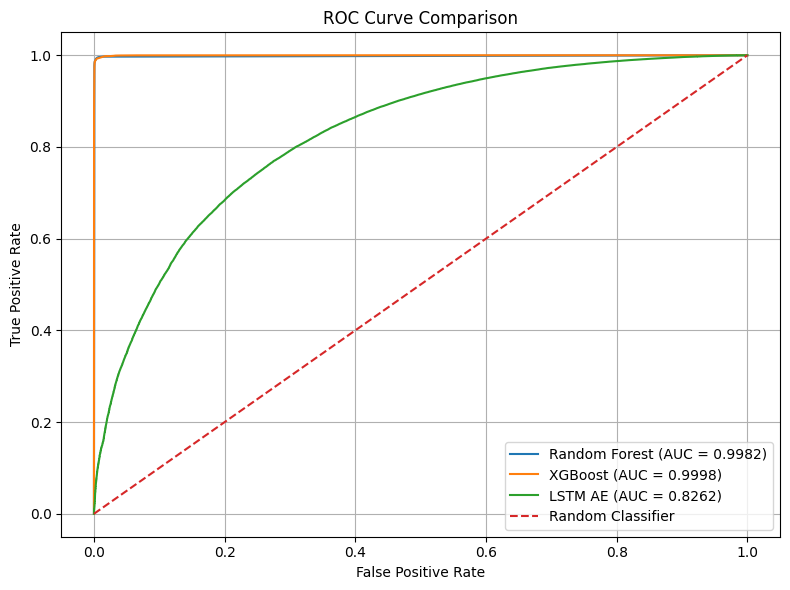

ROC-AUC Scores:
Random Forest ROC-AUC: 0.9982
XGBoost ROC-AUC      : 0.9998
LSTM AE ROC-AUC      : 0.8262


In [68]:
# =========================
# ROC Curve
# =========================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# LSTM Autoencoder ROC
# Reconstruction error is used as anomaly score
fpr_ae, tpr_ae, _ = roc_curve(y_test_seq, reconstruction_error)
roc_auc_ae = auc(fpr_ae, tpr_ae)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.4f})")
plt.plot(fpr_ae, tpr_ae, label=f"LSTM AE (AUC = {roc_auc_ae:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

# Save figure for thesis
plt.savefig("roc_curve_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

print("ROC-AUC Scores:")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")
print(f"XGBoost ROC-AUC      : {roc_auc_xgb:.4f}")
print(f"LSTM AE ROC-AUC      : {roc_auc_ae:.4f}")

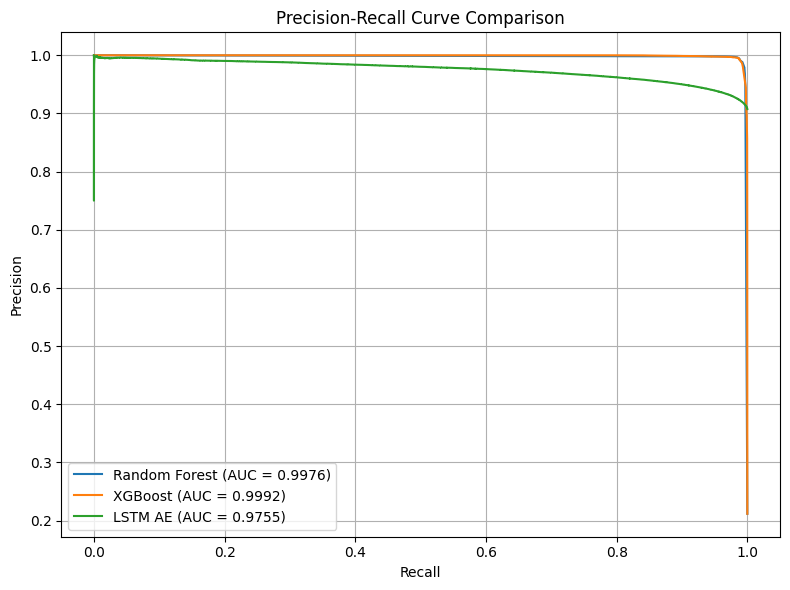

PR-AUC Scores:
Random Forest PR-AUC: 0.9976
XGBoost PR-AUC      : 0.9992
LSTM AE PR-AUC      : 0.9755


In [69]:
# =========================
# Precision-Recall Curve
# =========================

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Random Forest PR Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

# XGBoost PR Curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

# LSTM Autoencoder PR Curve
# Reconstruction error is used as anomaly score
precision_ae, recall_ae, _ = precision_recall_curve(
    y_test_seq,
    reconstruction_error
)

pr_auc_ae = auc(recall_ae, precision_ae)

# Plot curves
plt.figure(figsize=(8, 6))

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AUC = {pr_auc_rf:.4f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AUC = {pr_auc_xgb:.4f})"
)

plt.plot(
    recall_ae,
    precision_ae,
    label=f"LSTM AE (AUC = {pr_auc_ae:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig(
    "pr_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Print PR-AUC scores
print("PR-AUC Scores:")
print(f"Random Forest PR-AUC: {pr_auc_rf:.4f}")
print(f"XGBoost PR-AUC      : {pr_auc_xgb:.4f}")
print(f"LSTM AE PR-AUC      : {pr_auc_ae:.4f}")

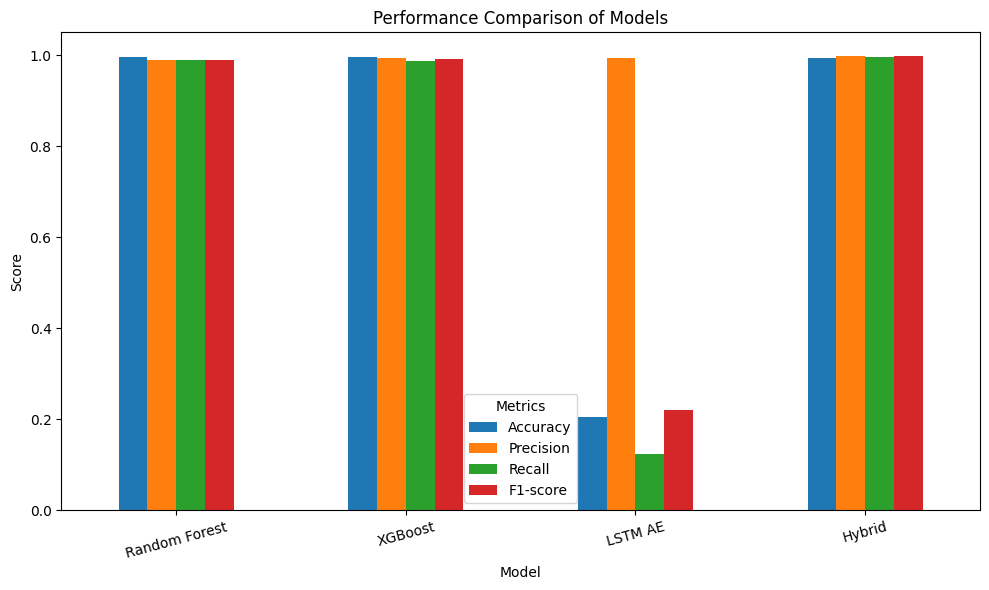

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# New model performance results
comparison_data = [
    ["Random Forest", 0.995829, 0.990185, 0.990095, 0.990140],
    ["XGBoost",       0.995998, 0.993904, 0.987134, 0.990508],
    ["LSTM AE",       0.203852, 0.993047, 0.123505, 0.219688],
    ["Hybrid",        0.994501, 0.997505, 0.996433, 0.996968]
]

df_comparison = pd.DataFrame(
    comparison_data,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

# Plot
ax = df_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(title="Metrics")
plt.tight_layout()

# Save for thesis
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

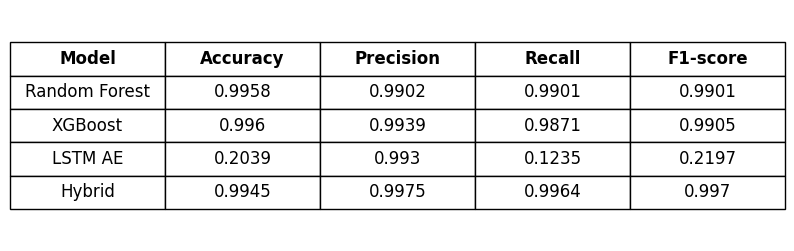

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Updated model performance values
comparison_data = {
    "Model": [
        "Random Forest",
        "XGBoost",
        "LSTM AE",
        "Hybrid"
    ],
    "Accuracy":  [0.9958, 0.9960, 0.2039, 0.9945],
    "Precision": [0.9902, 0.9939, 0.9930, 0.9975],
    "Recall":    [0.9901, 0.9871, 0.1235, 0.9964],
    "F1-score":  [0.9901, 0.9905, 0.2197, 0.9970]
}

df_comparison = pd.DataFrame(comparison_data)

# Create figure
fig, ax = plt.subplots(figsize=(10, 3))

# Hide axes
ax.axis('off')

# Create table
table = ax.table(
    cellText=df_comparison.values,
    colLabels=df_comparison.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

# Save image
plt.savefig(
    "performance_table_updated.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================
# 20. Unseen Attack Evaluation
# =========================

In [72]:
# Reload CICIDS
df_cic = pd.concat(df_cic_list, ignore_index=True)

# Reload IoT
df_iot = pd.read_csv(iot_path)

In [73]:
df_cic.columns = df_cic.columns.str.strip()

df_cic_selected = df_cic[[
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Label'
]].copy()

df_cic_selected.columns = [
    'dst_port',
    'duration',
    'src_pkts',
    'dst_pkts',
    'src_bytes',
    'dst_bytes',
    'attack_type'
]

df_cic_selected['label'] = df_cic_selected['attack_type'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

df_cic_selected['domain'] = 0

In [74]:
df_iot_selected = df_iot[[
    'dst_port',
    'duration',
    'src_pkts',
    'dst_pkts',
    'src_bytes',
    'dst_bytes',
    'label',
    'type'
]].copy()

df_iot_selected = df_iot_selected.rename(
    columns={'type': 'attack_type'}
)

df_iot_selected['label'] = df_iot_selected['label'].astype(int)

df_iot_selected['domain'] = 1

In [75]:
df_unseen = pd.concat(
    [df_cic_selected, df_iot_selected],
    ignore_index=True
)

df_unseen = df_unseen.drop_duplicates()
df_unseen = df_unseen.fillna(0)

df_unseen = df_unseen[df_unseen['duration'] >= 0]

In [76]:
features_to_transform = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'src_pkts',
    'dst_pkts'
]

for col in features_to_transform:
    df_unseen[col] = np.log1p(df_unseen[col])

In [77]:
print(df_unseen['attack_type'].value_counts())

attack_type
BENIGN                        1820603
DoS Hulk                       166335
DDoS                           127188
PortScan                        90743
normal                          23335
injection                       19790
password                        15339
dos                             14371
ddos                            12465
DoS GoldenEye                   10281
xss                              8546
scanning                         5541
DoS Slowhttptest                 5172
DoS slowloris                    4867
FTP-Patator                      4259
SSH-Patator                      3149
backdoor                         2274
Bot                              1936
Web Attack � Brute Force         1426
mitm                             1007
Web Attack � XSS                  651
ransomware                         56
Infiltration                       36
Web Attack � Sql Injection         20
Heartbleed                         11
Name: count, dtype: int64


In [82]:
unseen_attacks = [
    'ddos',
    'dos hulk',
    'dos goldeneye',
    'dos slowhttptest',
    'dos slowloris',
    'dos'
]

In [83]:
train_df = df_unseen[
    (df_unseen['label'] == 0) |
    (
        (df_unseen['label'] == 1) &
        (~df_unseen['attack_type'].isin(unseen_attacks))
    )
].copy()

In [84]:
test_df = df_unseen[
    (df_unseen['label'] == 0) |
    (df_unseen['attack_type'].isin(unseen_attacks))
].copy()

In [85]:
feature_cols = [
    'dst_port',
    'duration',
    'src_pkts',
    'dst_pkts',
    'src_bytes',
    'dst_bytes',
    'domain'
]

X_train = train_df[feature_cols]
y_train = train_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols
)

X_test = pd.DataFrame(
    X_test_scaled,
    columns=feature_cols
)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [87]:
xgb.fit(X_train, y_train)

y_pred_xgb_unknown = xgb.predict(X_test)

In [88]:
X_train_normal = X_train[y_train == 0].copy()

In [89]:
X_train_normal_seq = create_sequences(
    X_train_normal,
    seq_len=SEQ_LEN
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    seq_len=SEQ_LEN
)

In [90]:
X_test_recon = lstm_autoencoder.predict(
    X_test_seq,
    batch_size=256
)

reconstruction_error = np.mean(
    np.square(X_test_seq - X_test_recon),
    axis=(1, 2)
)

y_pred_ae_unknown = (
    reconstruction_error > best_threshold
).astype(int)

7308/7308 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step


In [91]:
y_pred_xgb_unknown_seq = create_sequence_labels_from_row_predictions(
    y_pred_xgb_unknown,
    seq_len=SEQ_LEN
)

In [92]:
y_pred_hybrid_unknown = np.logical_or(
    y_pred_xgb_unknown_seq,
    y_pred_ae_unknown
).astype(int)

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Unseen Attack Evaluation")

print("\nXGBoost")
print("Accuracy :", accuracy_score(y_test_seq, y_pred_xgb_unknown_seq))
print("Precision:", precision_score(y_test_seq, y_pred_xgb_unknown_seq))
print("Recall   :", recall_score(y_test_seq, y_pred_xgb_unknown_seq))
print("F1-score :", f1_score(y_test_seq, y_pred_xgb_unknown_seq))

print("\nLSTM Autoencoder")
print("Accuracy :", accuracy_score(y_test_seq, y_pred_ae_unknown))
print("Precision:", precision_score(y_test_seq, y_pred_ae_unknown))
print("Recall   :", recall_score(y_test_seq, y_pred_ae_unknown))
print("F1-score :", f1_score(y_test_seq, y_pred_ae_unknown))

print("\nHybrid Model")
print("Accuracy :", accuracy_score(y_test_seq, y_pred_hybrid_unknown))
print("Precision:", precision_score(y_test_seq, y_pred_hybrid_unknown))
print("Recall   :", recall_score(y_test_seq, y_pred_hybrid_unknown))
print("F1-score :", f1_score(y_test_seq, y_pred_hybrid_unknown))

Unseen Attack Evaluation

XGBoost
Accuracy : 0.9919102613102126
Precision: 0.6462741375434039
Recall   : 0.9637176382939094
F1-score : 0.7737005801782403

LSTM Autoencoder
Accuracy : 0.9679510788367326
Precision: 0.29920801445707146
Recall   : 0.9189793257589868
F1-score : 0.4514346362172449

Hybrid Model
Accuracy : 0.9621374143732644
Precision: 0.27157916601755205
Recall   : 0.9740733842428758
F1-score : 0.4247380817022659
